# 1-D Euler Equations — LF Scheme $\alpha$ Optimisation (PyTorch)

## Framework
| Component | Choice |
|-----------|--------|
| Equation  | 1D Euler (Sod shock tube, Case 1) |
| Parameter | `nn.Parameter` — unconstrained, $\alpha\in(-\infty,+\infty)$ |
| Optimiser | Adam warm-up → L-BFGS refinement |
| Loss      | MSE on conservative **Q** + $\lambda_\text{tv}$ TVD penalty on all $Q_k$ |
| Part 1    | scalar $\alpha$ (1 parameter) |
| Part 2    | space-time $\alpha_i(t)$ ($N$ parameters per step) |

## LF scheme for Euler
$$Q_i^{n+1}=Q_i^n-\frac{\Delta t}{2\Delta x}(F_{i+1}-F_{i-1})+\frac{\alpha\,\Delta t}{2\Delta x}(Q_{i+1}-2Q_i+Q_{i-1})$$

$Q=[\rho,\;\rho u,\;E]$,  $F=[\rho u,\;\rho u^2+p,\;u(E+p)]$,  $p=(\gamma-1)(E-\tfrac{1}{2}\rho u^2)$.

Standard LF: $\alpha=\Delta x \Delta t = \lambda_{max} \text{CFL}$ where $\lambda_{max}=max(|u|+c)$.  
Negative $\alpha$ = anti-diffusion (sharpening); TVD penalty on all 3 conservative components prevents oscillations in $u$ and $p$.

## Combined loss
$$\mathcal{L}=\underbrace{\frac{1}{3N}\sum_{k,i}(Q_{k,i}^{n+1}-Q_{k,i}^\text{exact})^2}_{\mathcal{L}_\text{mse}}+\lambda_\text{tv}\,\underbrace{\max\!\left(0,\;\sum_k\mathrm{TV}(Q_k^{n+1})-\sum_k\mathrm{TV}(Q_k^n)\right)}_{\mathcal{L}_\text{tvd}}$$

Exact solution from the analytical Riemann solver.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

GAMMA = 1.4

# Grid (cell-centred FVM)
L, N = 1.0, 200
dx   = L / N
x_np = np.linspace(dx/2, L - dx/2, N)

# Sod's shock tube IC (membrane at x = 0.5)
rhoL, uL, pL = 1.0,   0.0, 1.0
rhoR, uR, pR = 0.125, 0.0, 0.1
T_final = 0.20
CFL     = 0.40

def prim2cons_np(rho, u, p):
    E = p / (GAMMA - 1) + 0.5 * rho * u**2
    return np.array([rho, rho * u, E])   # (3,) or (3, N)

Q_L_bc_np = prim2cons_np(rhoL, uL, pL)   # (3,) left Dirichlet ghost
Q_R_bc_np = prim2cons_np(rhoR, uR, pR)   # (3,) right Dirichlet ghost
Q_L_bc    = torch.from_numpy(Q_L_bc_np)
Q_R_bc    = torch.from_numpy(Q_R_bc_np)

rho0 = np.where(x_np < 0.5, rhoL, rhoR)
u0   = np.where(x_np < 0.5, uL,   uR)
p0   = np.where(x_np < 0.5, pL,   pR)
Q_init_np = prim2cons_np(rho0, u0, p0)   # (3, N)
Q_init    = torch.from_numpy(Q_init_np.copy())

# ── Exact Riemann solver (Gottlieb-Groth) ────────────────────────────────────
def exact_riemann_solver(x, t, rho1, u1, p1, rho4, u4, p4):
    alp  = (GAMMA + 1) / (GAMMA - 1)
    c1   = np.sqrt(GAMMA * p1 / rho1)
    c4   = np.sqrt(GAMMA * p4 / rho4)
    PRL  = p4 / p1;   CRL = c4 / c1
    MACHLEFT = (u1 - u4) / c1

    def f(P):
        term = (1 + MACHLEFT*(GAMMA-1)/2
                - (GAMMA-1)*CRL*(P-1)/np.sqrt(2*GAMMA*(GAMMA-1+(GAMMA+1)*P)))
        if term < 0:
            return -1e10
        return (term**(2*GAMMA/(GAMMA-1))) / P - PRL

    try:
        sol = root_scalar(f, bracket=[1e-6, 1e4], method='brentq')
        p34 = sol.root
    except ValueError:
        p34 = 3.0

    p3   = p34 * p4
    rho3 = rho4 * (1 + alp * p34) / (alp + p34)
    rho2 = rho1 * (p34 * p4 / p1)**(1 / GAMMA)
    u2   = u1 - u4 + (2/(GAMMA-1))*c1*(1 - (p34*p4/p1)**((GAMMA-1)/(2*GAMMA)))
    c2   = np.sqrt(GAMMA * p3 / rho2)

    x0   = 0.5
    spos = x0 + t*c4*np.sqrt((GAMMA-1)/(2*GAMMA) + (GAMMA+1)/(2*GAMMA)*p34) + t*u4
    cpos = x0 + u2*t + t*u4
    pos1 = x0 + (u1 - c1)*t
    pos2 = x0 + (u2 + u4 - c2)*t

    rho_e, u_e, p_e = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    for i in range(len(x)):
        xi = x[i]
        if t == 0:
            rho_e[i], u_e[i], p_e[i] = (rho1,u1,p1) if xi <= x0 else (rho4,u4,p4)
        elif xi <= pos1:
            rho_e[i], u_e[i], p_e[i] = rho1, u1, p1
        elif xi <= pos2:
            p_e[i]   = p1*(1+(pos1-xi)/(c1*alp*t))**(2*GAMMA/(GAMMA-1))
            rho_e[i] = rho1*(1+(pos1-xi)/(c1*alp*t))**(2/(GAMMA-1))
            u_e[i]   = u1 + (2/(GAMMA+1))*(xi-pos1)/t
        elif xi <= cpos:
            rho_e[i], u_e[i], p_e[i] = rho2, u2+u4, p3
        elif xi <= spos:
            rho_e[i], u_e[i], p_e[i] = rho3, u2+u4, p3
        else:
            rho_e[i], u_e[i], p_e[i] = rho4, u4, p4
    return rho_e, u_e, p_e

# Returns exact Q = [rho, rho*u, E] as (3, N) torch tensor at time t
def exact_conservative(t):
    rho_e, u_e, p_e = exact_riemann_solver(x_np, t, rhoL, uL, pL, rhoR, uR, pR)
    E_e = p_e / (GAMMA - 1) + 0.5 * rho_e * u_e**2
    return torch.from_numpy(np.stack([rho_e, rho_e*u_e, E_e], axis=0))

# ── Standard LF baseline (numpy) ─────────────────────────────────────────────
def euler_flux_np(Q):
    rho = np.maximum(Q[0], 1e-10)
    vel = Q[1] / rho
    E   = Q[2]
    p   = np.maximum((GAMMA-1)*(E - 0.5*rho*vel**2), 1e-10)
    return np.array([rho*vel, rho*vel**2 + p, vel*(E+p)])

def lf_np(Q, alpha, dt):
    Q_ext = np.hstack([Q_L_bc_np[:, None], Q, Q_R_bc_np[:, None]])   # (3, N+2)
    F_ext = euler_flux_np(Q_ext)
    Q_p, Q_m = Q_ext[:, 2:], Q_ext[:, :-2]
    F_p, F_m = F_ext[:, 2:], F_ext[:, :-2]
    return Q - (dt/(2*dx))*(F_p - F_m) + (alpha*dt/(2*dx))*(Q_p - 2*Q + Q_m)

def get_dt(Q_np):
    rho = np.maximum(Q_np[0], 1e-10)
    vel = Q_np[1] / rho
    p   = np.maximum((GAMMA-1)*(Q_np[2] - 0.5*rho*vel**2), 1e-10)
    c   = np.sqrt(GAMMA * p / rho)
    return CFL * dx / np.max(np.abs(vel) + c)

# Run standard LF to T_final (variable dt, no re-optimisation)
Q_std  = Q_init_np.copy()
t_cur  = 0.0;  dt_all = []
while t_cur < T_final:
    dt_n  = min(get_dt(Q_std), T_final - t_cur)
    Q_std = lf_np(Q_std, dx / dt_n, dt_n)
    dt_all.append(dt_n);  t_cur += dt_n

n_steps_std    = len(dt_all)
alpha_std_mean = dx / np.mean(dt_all)

rho_ex_f, u_ex_f, p_ex_f = exact_riemann_solver(x_np, T_final, rhoL, uL, pL, rhoR, uR, pR)
E_ex_f  = p_ex_f / (GAMMA-1) + 0.5 * rho_ex_f * u_ex_f**2
Q_ex_f  = np.stack([rho_ex_f, rho_ex_f*u_ex_f, E_ex_f], axis=0)

print(f"dx={dx:.4f}  CFL={CFL}  n_steps={n_steps_std}")
print(f"mean alpha_std (dx/dt): {alpha_std_mean:.4f}")
print(f"MSE standard LF (all Q): {np.mean((Q_std - Q_ex_f)**2):.4e}")
print(f"MSE density only:         {np.mean((Q_std[0] - Q_ex_f[0])**2):.4e}")


dx=0.0050  CFL=0.4  n_steps=203
mean alpha_std (dx/dt): 5.0750
MSE standard LF (all Q): 6.0260e-03
MSE density only:         1.9112e-03


In [2]:
# ── Differentiable PyTorch utilities ─────────────────────────────────────────
def euler_flux_torch(Q):
    rho = Q[0];  vel = Q[1] / rho;  E = Q[2]
    p   = (GAMMA - 1) * (E - 0.5 * rho * vel**2)
    return torch.stack([rho*vel, rho*vel**2 + p, vel*(E+p)], dim=0)

def lf_torch(Q, alpha, dt):
    # alpha: scalar or shape (N,); Dirichlet ghosts Q_L_bc, Q_R_bc from cell 1.
    Q_ext = torch.cat([Q_L_bc.unsqueeze(1), Q, Q_R_bc.unsqueeze(1)], dim=1)
    F_ext = euler_flux_torch(Q_ext)
    Q_p, Q_m = Q_ext[:, 2:], Q_ext[:, :-2]
    F_p, F_m = F_ext[:, 2:], F_ext[:, :-2]
    lap = Q_p - 2*Q + Q_m
    return Q - (dt/(2*dx))*(F_p - F_m) + (alpha*dt/(2*dx))*lap

def total_var_rho(Q):
    rho = Q[0]
    return torch.sum(torch.abs(rho[1:] - rho[:-1]))

def tvd_penalty_Q(Q_old, Q_new):
    # Per-component independent relu: penalises TV increase in ANY component.
    # Using sum(relu(TV_k_new - TV_k_old)) rather than relu(sum TV_k_new - sum TV_k_old)
    # prevents components from cancelling each other and missing oscillations.
    pen = Q_new.new_zeros(())
    for k in range(3):
        tv_old = torch.sum(torch.abs(Q_old[k, 1:] - Q_old[k, :-1]))
        tv_new = torch.sum(torch.abs(Q_new[k, 1:] - Q_new[k, :-1]))
        pen = pen + F.relu(tv_new - tv_old)
    return pen

def step_loss(Q_old, alpha, dt, Q_ex, lam_tv=0.01):
    Q_new = lf_torch(Q_old, alpha, dt)
    mse   = torch.mean((Q_new - Q_ex)**2)
    tvd   = tvd_penalty_Q(Q_old, Q_new)
    return mse + lam_tv * tvd, Q_new

print("euler_flux_torch, lf_torch, tvd_penalty_Q, step_loss defined.")


euler_flux_torch, lf_torch, tvd_penalty_Q, step_loss defined.


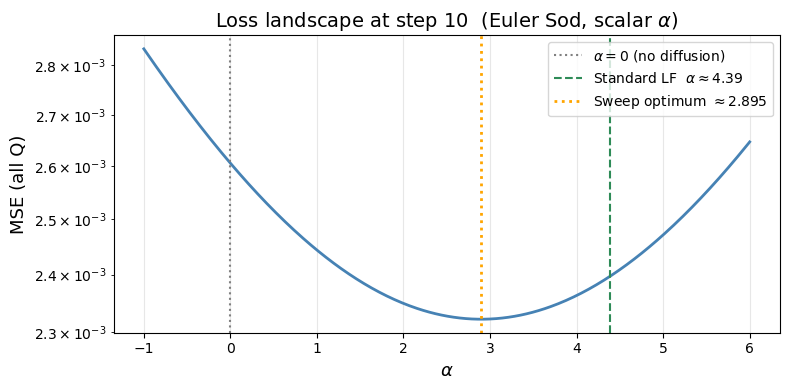

Sweep optimal alpha: 2.8947  |  Standard LF: 4.3908


In [3]:
# Loss landscape: sweep alpha at step 10 (after 10 std-LF steps from IC)
Q_demo, t_demo = Q_init_np.copy(), 0.0
for _ in range(10):
    dt_n   = min(get_dt(Q_demo), T_final - t_demo)
    Q_demo = lf_np(Q_demo, dx/dt_n, dt_n)
    t_demo += dt_n

dt_next      = get_dt(Q_demo)
alpha_std_lc = dx / dt_next
Q_ex_demo    = exact_conservative(t_demo + dt_next).numpy()

alphas_sw = np.linspace(-1.0, 6.0, 400)
mse_sw    = [np.mean((lf_np(Q_demo, a, dt_next) - Q_ex_demo)**2) for a in alphas_sw]
opt_a     = alphas_sw[np.argmin(mse_sw)]

plt.figure(figsize=(8, 4))
plt.plot(alphas_sw, mse_sw, 'steelblue', lw=2)
plt.axvline(0,            color='gray',     ls=':',  lw=1.5, label=r'$\alpha=0$ (no diffusion)')
plt.axvline(alpha_std_lc, color='seagreen', ls='--', lw=1.5,
            label=f'Standard LF  $\\alpha\\approx{alpha_std_lc:.2f}$')
plt.axvline(opt_a,        color='orange',   ls=':',  lw=2,
            label=f'Sweep optimum $\\approx{opt_a:.3f}$')
plt.xlabel(r'$\alpha$', fontsize=13); plt.ylabel('MSE (all Q)', fontsize=13)
plt.title('Loss landscape at step 10  (Euler Sod, scalar $\\alpha$)', fontsize=14)
plt.yscale('log'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"Sweep optimal alpha: {opt_a:.4f}  |  Standard LF: {alpha_std_lc:.4f}")


 Step |    alpha |      MSE (Q) |    TVD pen
----------------------------------------------------
   25 |  0.82956 |   2.0988e-03 | 0.0000e+00
   50 |  1.92063 |   1.8761e-03 | 0.0000e+00
   75 |  1.65890 |   1.9015e-03 | 0.0000e+00
  100 |  1.53314 |   1.9273e-03 | 0.0000e+00
  125 |  1.22246 |   1.9581e-03 | 0.0000e+00
  150 |  2.04512 |   1.9840e-03 | 0.0000e+00
  175 |  2.09169 |   1.9846e-03 | 6.0799e-06
  200 |  2.02273 |   1.9855e-03 | 1.0723e-05

Total steps: 213


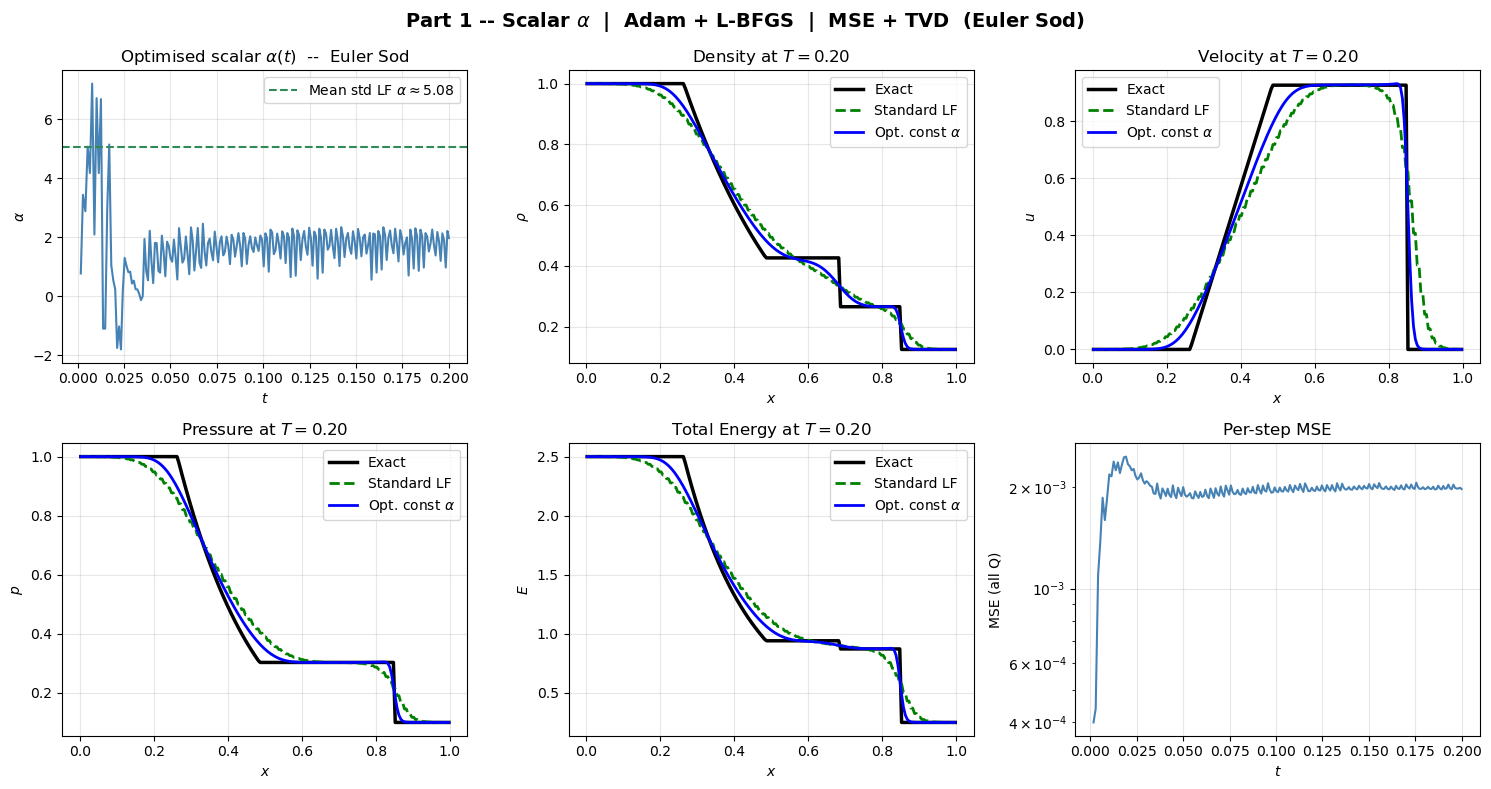


MSE opt const alpha (all Q): 1.9759e-03
MSE standard LF (all Q):     6.0260e-03


In [4]:
# =====================================================================
# Part 1 -- Scalar alpha  |  nn.Parameter  |  Adam -> L-BFGS  |  MSE+TVD
# =====================================================================
N_ADAM  = 80;  LR_ADAM  = 0.3
N_LBFGS = 10;  LR_LBFGS = 0.2
LAM_TV  = 0.01

Q_c    = Q_init.clone()
Q_np_c = Q_init_np.copy()
raw_c  = nn.Parameter(torch.tensor(dx / get_dt(Q_np_c)))  # init at alpha_std
alpha_log_c, mse_log_c, t_log_c = [], [], []
t_cur, step = 0.0, 0

print(f"{'Step':>5} | {'alpha':>8} | {'MSE (Q)':>12} | {'TVD pen':>10}")
print("-" * 52)

while t_cur < T_final:
    dt_n  = float(min(get_dt(Q_np_c), T_final - t_cur))
    t_nxt = t_cur + dt_n
    Q_ex  = exact_conservative(t_nxt)
    Q_old = Q_c.detach()

    raw = nn.Parameter(raw_c.detach().clone())

    opt_adam = torch.optim.Adam([raw], lr=LR_ADAM)
    for _ in range(N_ADAM):
        opt_adam.zero_grad()
        loss, _ = step_loss(Q_old, raw, dt_n, Q_ex, LAM_TV)
        loss.backward(); opt_adam.step()

    opt_lbfgs = torch.optim.LBFGS([raw], lr=LR_LBFGS, max_iter=10,
                                    history_size=10, tolerance_grad=1e-5,
                                    line_search_fn='strong_wolfe')
    def closure_c():
        opt_lbfgs.zero_grad()
        loss, _ = step_loss(Q_old, raw, dt_n, Q_ex, LAM_TV)
        loss.backward(); return loss
    for _ in range(N_LBFGS):
        opt_lbfgs.step(closure_c)

    with torch.no_grad():
        alpha_opt = raw.item()
        Q_c       = lf_torch(Q_old, alpha_opt, dt_n).detach()
        Q_np_c    = Q_c.numpy().copy()
        raw_c     = raw.detach()

    mse_v = torch.mean((Q_c - Q_ex)**2).item()
    tvd_v = F.relu(total_var_rho(Q_c) - total_var_rho(Q_old)).item()
    alpha_log_c.append(alpha_opt);  mse_log_c.append(mse_v);  t_log_c.append(t_nxt)
    t_cur = t_nxt;  step += 1
    if step % 25 == 0:
        print(f"{step:>5} | {alpha_opt:>8.5f} | {mse_v:>12.4e} | {tvd_v:>10.4e}")

print(f"\nTotal steps: {step}")
t_arr = np.array(t_log_c)

# ── Extract primitives at T_final ────────────────────────────────────────────
rho_opt = Q_c.numpy()[0]
u_opt   = Q_c.numpy()[1] / rho_opt
p_opt   = (GAMMA-1)*(Q_c.numpy()[2] - 0.5*rho_opt*u_opt**2)

u_std_f = Q_std[1] / Q_std[0]
p_std_f = (GAMMA-1)*(Q_std[2] - 0.5*Q_std[0]*u_std_f**2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(t_arr, alpha_log_c, 'steelblue', lw=1.5)
axes[0, 0].axhline(alpha_std_mean, color='seagreen', ls='--',
                   label=f'Mean std LF $\\alpha\\approx{alpha_std_mean:.2f}$')
axes[0, 0].set_xlabel('$t$'); axes[0, 0].set_ylabel(r'$\alpha$')
axes[0, 0].set_title('Optimised scalar $\\alpha(t)$  --  Euler Sod')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

pairs = [
    (axes[0,1], rho_ex_f, Q_std[0],   rho_opt, r'$\rho$', 'Density'),
    (axes[0,2], u_ex_f,   u_std_f,    u_opt,   r'$u$',    'Velocity'),
    (axes[1,0], p_ex_f,   p_std_f,    p_opt,   r'$p$',    'Pressure'),
    (axes[1,1], E_ex_f,   Q_std[2],   Q_c.numpy()[2], r'$E$', 'Total Energy'),
]
for ax, ex, std, opt, ylabel, title in pairs:
    ax.plot(x_np, ex,  'k-',  lw=2.5, label='Exact')
    ax.plot(x_np, std, 'g--', lw=2,   label='Standard LF')
    ax.plot(x_np, opt, 'b-',  lw=2,   label='Opt. const $\\alpha$')
    ax.set_xlabel('$x$'); ax.set_ylabel(ylabel)
    ax.set_title(f'{title} at $T={T_final:.2f}$'); ax.legend(); ax.grid(alpha=0.3)

axes[1, 2].semilogy(t_arr, mse_log_c, 'steelblue', lw=1.5)
axes[1, 2].set_xlabel('$t$'); axes[1, 2].set_ylabel('MSE (all Q)')
axes[1, 2].set_title('Per-step MSE'); axes[1, 2].grid(alpha=0.3)

plt.suptitle('Part 1 -- Scalar $\\alpha$  |  Adam + L-BFGS  |  MSE + TVD  (Euler Sod)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

mse_c_final = np.mean((Q_c.numpy() - Q_ex_f)**2)
print(f"\nMSE opt const alpha (all Q): {mse_c_final:.4e}")
print(f"MSE standard LF (all Q):     {np.mean((Q_std - Q_ex_f)**2):.4e}")


 Step | mean alpha |  min alpha |      MSE (Q)
--------------------------------------------------
   50 |    2.88829 |  -24.41200 |   2.6029e-04
  100 |    2.69317 |  -27.29267 |   1.9033e-04
  150 |    2.70935 |  -15.35102 |   1.8067e-04
  200 |    3.40245 |  -17.30780 |   1.3546e-04

Total steps: 210


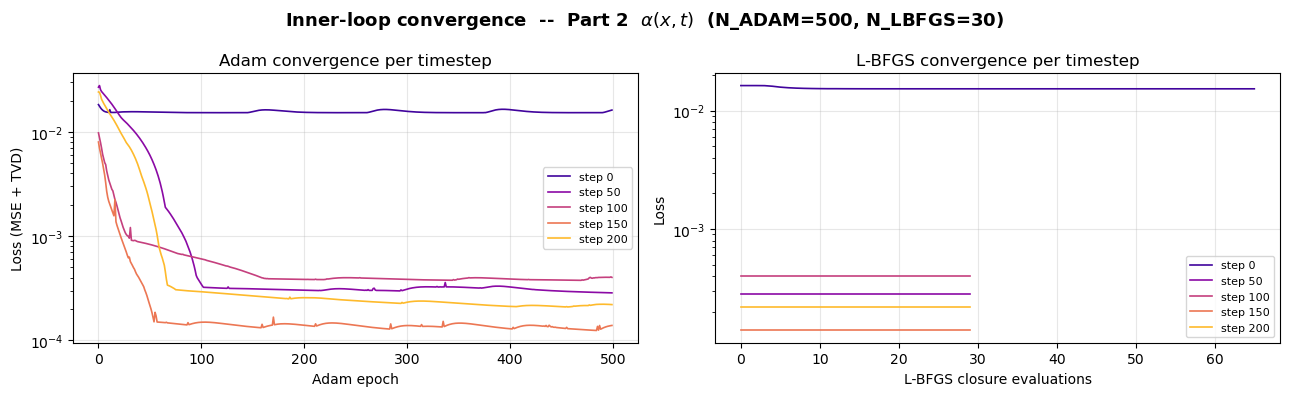

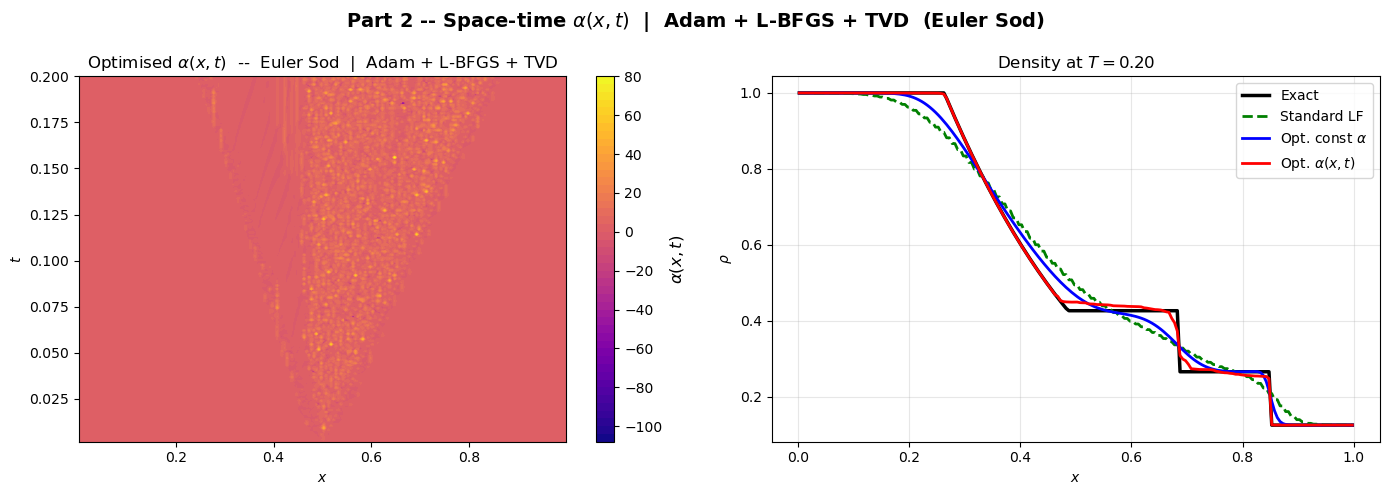

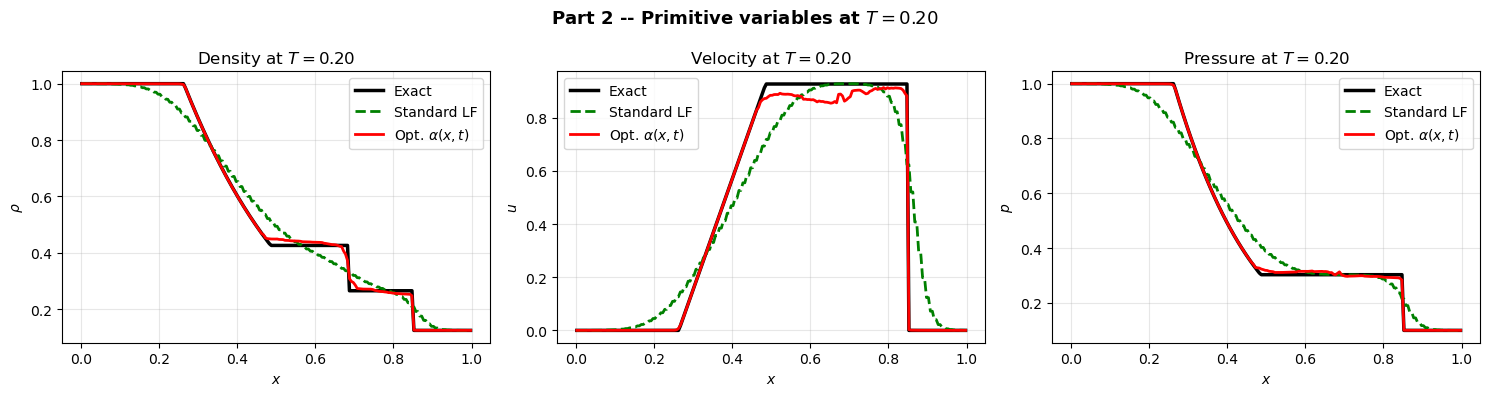


MSE opt space-time alpha (all Q): 1.2959e-04
MSE opt const alpha (all Q):      1.9759e-03
MSE standard LF (all Q):          6.0260e-03


In [5]:
# =====================================================================
# Part 2 -- Space-time alpha_i(t)  |  N params  |  Adam -> L-BFGS
# Per-component TVD, more epochs, loss-over-epochs logging.
# =====================================================================
N_ADAM_S  = 500;  LR_ADAM_S  = 0.3
N_LBFGS_S = 30;   LR_LBFGS_S = 0.2
LAM_TV_S  = 0.05   # tighter than Part 1; space-time has more freedom to oscillate

Q_s    = Q_init.clone()
Q_np_s = Q_init_np.copy()
raw_s  = nn.Parameter(torch.full((N,), dx / get_dt(Q_np_s)))
alpha_st, t_st = [], []
t_cur_s, step_s = 0.0, 0

# Inner-loop loss logs for every LOG_EVERY-th timestep
LOG_EVERY  = 50
conv_adam  = {}   # step_s -> [loss per Adam epoch]
conv_lbfgs = {}   # step_s -> [loss per L-BFGS closure eval]

print(f"{'Step':>5} | {'mean alpha':>10} | {'min alpha':>10} | {'MSE (Q)':>12}")
print("-" * 50)

while t_cur_s < T_final:
    dt_n  = float(min(get_dt(Q_np_s), T_final - t_cur_s))
    t_nxt = t_cur_s + dt_n
    Q_ex  = exact_conservative(t_nxt)
    Q_old = Q_s.detach()

    raw    = nn.Parameter(raw_s.detach().clone())
    do_log = (step_s % LOG_EVERY == 0)

    # ── Adam phase ────────────────────────────────────────────────────────────
    adam_buf = [] if do_log else None
    opt_adam = torch.optim.Adam([raw], lr=LR_ADAM_S)
    for _ in range(N_ADAM_S):
        opt_adam.zero_grad()
        loss, _ = step_loss(Q_old, raw, dt_n, Q_ex, LAM_TV_S)
        loss.backward();  opt_adam.step()
        if adam_buf is not None:
            adam_buf.append(loss.item())
    if do_log:
        conv_adam[step_s] = adam_buf

    # ── L-BFGS phase ─────────────────────────────────────────────────────────
    lbfgs_buf = [] if do_log else None
    opt_lbfgs = torch.optim.LBFGS([raw], lr=LR_LBFGS_S, max_iter=10,
                                    history_size=10, tolerance_grad=1e-7,
                                    line_search_fn='strong_wolfe')
    def closure_s():
        opt_lbfgs.zero_grad()
        loss, _ = step_loss(Q_old, raw, dt_n, Q_ex, LAM_TV_S)
        loss.backward()
        if lbfgs_buf is not None:
            lbfgs_buf.append(loss.item())
        return loss
    for _ in range(N_LBFGS_S):
        opt_lbfgs.step(closure_s)
    if do_log:
        conv_lbfgs[step_s] = lbfgs_buf

    with torch.no_grad():
        alpha_opt = raw.detach()
        Q_s       = lf_torch(Q_old, alpha_opt, dt_n).detach()
        Q_np_s    = Q_s.numpy().copy()
        raw_s     = raw.detach()

    alpha_st.append(alpha_opt.numpy().copy());  t_st.append(t_nxt)
    t_cur_s = t_nxt;  step_s += 1
    if step_s % 50 == 0:
        mse_v = torch.mean((Q_s - Q_ex)**2).item()
        print(f"{step_s:>5} | {alpha_opt.mean().item():>10.5f} | "
              f"{alpha_opt.min().item():>10.5f} | {mse_v:>12.4e}")

alpha_st_arr = np.array(alpha_st)   # (n_steps, N)
print(f"\nTotal steps: {step_s}")

# ── Plot 1: Inner-loop convergence ────────────────────────────────────────────
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(conv_adam)))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (s, losses) in enumerate(sorted(conv_adam.items())):
    axes[0].semilogy(losses, color=colors[i], lw=1.2, label=f'step {s}')
axes[0].set_xlabel('Adam epoch');  axes[0].set_ylabel('Loss (MSE + TVD)')
axes[0].set_title('Adam convergence per timestep');  axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for i, (s, losses) in enumerate(sorted(conv_lbfgs.items())):
    axes[1].semilogy(losses, color=colors[i], lw=1.2, label=f'step {s}')
axes[1].set_xlabel('L-BFGS closure evaluations');  axes[1].set_ylabel('Loss')
axes[1].set_title('L-BFGS convergence per timestep');  axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle(r'Inner-loop convergence  --  Part 2  $\alpha(x,t)$  (N_ADAM=500, N_LBFGS=30)',
             fontsize=13, fontweight='bold')
plt.tight_layout();  plt.show()

# ── Plot 2: alpha(x,t) contour + density ─────────────────────────────────────
T_g, X_g = np.meshgrid(t_st, x_np)
rho_s = Q_s.numpy()[0];  u_s = Q_s.numpy()[1] / rho_s
p_s   = (GAMMA-1)*(Q_s.numpy()[2] - 0.5*rho_s*u_s**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cp = axes[0].contourf(X_g, T_g, alpha_st_arr.T, levels=60, cmap='plasma')
plt.colorbar(cp, ax=axes[0]).set_label(r'$\alpha(x,t)$', fontsize=12)
axes[0].set_xlabel('$x$');  axes[0].set_ylabel('$t$')
axes[0].set_title(r'Optimised $\alpha(x,t)$  --  Euler Sod  |  Adam + L-BFGS + TVD')

axes[1].plot(x_np, rho_ex_f,       'k-',  lw=2.5, label='Exact')
axes[1].plot(x_np, Q_std[0],       'g--', lw=2,   label='Standard LF')
axes[1].plot(x_np, Q_c.numpy()[0], 'b-',  lw=2,   label='Opt. const $\\alpha$')
axes[1].plot(x_np, rho_s,          'r-',  lw=2,   label=r'Opt. $\alpha(x,t)$')
axes[1].set_xlabel('$x$');  axes[1].set_ylabel(r'$\rho$')
axes[1].set_title(f'Density at $T={T_final:.2f}$')
axes[1].legend();  axes[1].grid(alpha=0.3)

plt.suptitle(r'Part 2 -- Space-time $\alpha(x,t)$  |  Adam + L-BFGS + TVD  (Euler Sod)',
             fontsize=14, fontweight='bold')
plt.tight_layout();  plt.show()

# ── Plot 3: Primitive variables ───────────────────────────────────────────────
u_std_f2 = Q_std[1]/Q_std[0]
p_std_f2 = (GAMMA-1)*(Q_std[2] - 0.5*Q_std[0]*u_std_f2**2)

fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))
pairs2 = [
    (ax2[0], rho_ex_f, Q_std[0],  rho_s, r'$\rho$', 'Density'),
    (ax2[1], u_ex_f,   u_std_f2,  u_s,   r'$u$',    'Velocity'),
    (ax2[2], p_ex_f,   p_std_f2,  p_s,   r'$p$',    'Pressure'),
]
for ax, ex, std, opt, ylabel, title in pairs2:
    ax.plot(x_np, ex,  'k-',  lw=2.5, label='Exact')
    ax.plot(x_np, std, 'g--', lw=2,   label='Standard LF')
    ax.plot(x_np, opt, 'r-',  lw=2,   label=r'Opt. $\alpha(x,t)$')
    ax.set_xlabel('$x$');  ax.set_ylabel(ylabel)
    ax.set_title(f'{title} at $T={T_final:.2f}$');  ax.legend();  ax.grid(alpha=0.3)

plt.suptitle(r'Part 2 -- Primitive variables at $T=0.20$', fontsize=13, fontweight='bold')
plt.tight_layout();  plt.show()

mse_s_final = np.mean((Q_s.numpy() - Q_ex_f)**2)
print(f"\nMSE opt space-time alpha (all Q): {mse_s_final:.4e}")
print(f"MSE opt const alpha (all Q):      {mse_c_final:.4e}")
print(f"MSE standard LF (all Q):          {np.mean((Q_std - Q_ex_f)**2):.4e}")
